<h1>Project 1: Data Analysis Project<h1>

<h2> 1 - Inequality in Denmark

In [1]:
%pip install git+https://github.com/alemartinello/dstapi
%pip install fredapi

  Cloning https://github.com/alemartinello/dstapi to /private/var/folders/9f/_qwhm7hj7nx54tbqjl50k1900000gn/T/pip-req-build-bpk97nsn
  Running command git clone --filter=blob:none --quiet https://github.com/alemartinello/dstapi /private/var/folders/9f/_qwhm7hj7nx54tbqjl50k1900000gn/T/pip-req-build-bpk97nsn
  Resolved https://github.com/alemartinello/dstapi to commit d9eeb5a82cbc70b7d63b2ff44d92632fd77123a4
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from dstapi import DstApi
import pandas as pd

colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
plt.rcParams.update({'axes.grid':True,'grid.color':'black','grid.alpha':'0.25','grid.linestyle':'--'})
plt.rcParams.update({'font.size': 14})


In [3]:
IFOR41 = DstApi('IFOR41')
IFOR41.tablesummary(language='en')
IFOR32 = DstApi('IFOR32')
IFOR32.tablesummary(language='en')

Table IFOR41: Income distribution on equivalised disposable income by indicator, municipality and time
Last update: 2025-12-01T08:00:00
Table IFOR32: Avg. equivalised disposable Income in decile groups, by decile average, municipality and time
Last update: 2025-12-01T08:00:00


,variable name,# values,First value,First value label,Last value,Last value label,Time variable
0,DECILGEN,10,1DC,First decil,10DC,Tenth decil,False
1,KOMMUNEDK,99,000,All Denmark,851,Aalborg,False
2,Tid,38,1987,1987,2024,2024,True


In [4]:
IFOR41.variable_levels('ULLIG',language='en') ##might not be necessary

,id,text
0,70,Gini coefficient
1,71,Hoover index
2,72,S80/S20 (Income quintile share ratio)
3,73,P90/10 (Upper decile boundary divided by lower)


In [5]:
# a. set download parameters
params = {
    'table': 'IFOR41',
    'format': 'BULK', # semicolon separated file
    'lang': 'en',
    'variables': [
        {'code': 'ULLIG', 'values': ['70']},
        {'code': 'KOMMUNEDK', 'values': ['000']},
        {'code': 'Tid', 'values': ['*']}, # '*' is everything
        ]
    }

# b. download
Gini = IFOR41.get_data(params=params)

# c. display
display(Gini.head(5)) ##maybe just display(Gini) but it might be long
display(Gini.info())

,ULLIG,KOMMUNEDK,TID,INDHOLD
0,Gini coefficient,All Denmark,2016,28.97
1,Gini coefficient,All Denmark,1999,23.83
2,Gini coefficient,All Denmark,1988,22.06
3,Gini coefficient,All Denmark,2015,28.77
4,Gini coefficient,All Denmark,1989,21.93


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38 entries, 0 to 37
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   ULLIG      38 non-null     object
 1   KOMMUNEDK  38 non-null     object
 2   TID        38 non-null     int64 
 3   INDHOLD    38 non-null     object
dtypes: int64(1), object(3)
memory usage: 1.3+ KB


None

In [6]:
Gini = Gini.drop(columns=['KOMMUNEDK','ULLIG'])
Gini = Gini.rename(columns={'INDHOLD': 'Gini Coefficient', 'TID': 'year'}) #Change the variable name
Gini = Gini.set_index('year').sort_index() #Sort after year

display(Gini)

,Gini Coefficient
year,
1987,22.07
1988,22.06
1989,21.93
1990,22.16
1991,21.99
1992,22.34
1993,22.79
1994,22.50
1995,22.41


KeyError: 'Gini_coefficient'

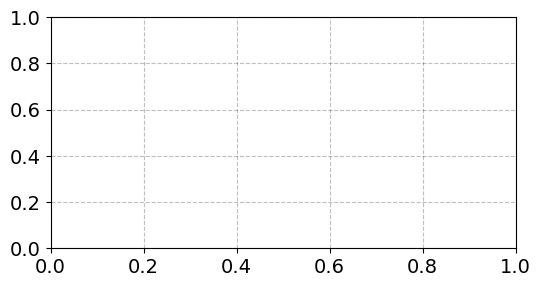

In [7]:
fig = plt.figure(figsize=(6,3))
ax = fig.add_subplot()
ax.plot(Gini.index, Gini['Gini_coefficient'].astype(float))
ax.set_title("Gini coefficient in Denmark 1987-2024")
ax.set_xlabel('Year')
ax.set_ylabel('Gini coefficient')
ax.set_ylim(20, 32)
ax.set_yticks(np.arange(20, 33, 2))
print(Gini)

In [8]:
IFOR32.tablesummary(language='en')

Table IFOR32: Avg. equivalised disposable Income in decile groups, by decile average, municipality and time
Last update: 2025-12-01T08:00:00


,variable name,# values,First value,First value label,Last value,Last value label,Time variable
0,DECILGEN,10,1DC,First decil,10DC,Tenth decil,False
1,KOMMUNEDK,99,000,All Denmark,851,Aalborg,False
2,Tid,38,1987,1987,2024,2024,True


In [10]:
params = {
    'table': 'IFOR32',
    'format': 'BULK', 
    'lang': 'en',
    'variables': [
        {'code': 'DECILGEN', 'values': ['1DC']},
        {'code': 'KOMMUNEDK', 'values': ['000']},
        {'code': 'Tid', 'values': ['*']}, 
        ]
    }

top10 = IFOR32.get_data(params=params)
top10.head(5)

,DECILGEN,KOMMUNEDK,TID,INDHOLD
0,First decil,All Denmark,1987,31418
1,First decil,All Denmark,1988,32746
2,First decil,All Denmark,1989,35284
3,First decil,All Denmark,1990,36480
4,First decil,All Denmark,1991,40715
